In [27]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")



In [28]:
df = pd.read_csv("../data/predicted/train_predicted_xgboost_baseline_regularization_subset_added_velocity_features_removed_online_added_mcc_risk_score_velocity_errors.csv", parse_dates=["date"])


In [29]:
df.dropna(subset = ["predicted_prob"], axis = 0, inplace=True)
df["predicted_class"] = df["predicted_prob"]>0.5

In [30]:
mapping = {True:"Yes", False:"No"}
df["predicted_class"] = df["predicted_class"].map(mapping)

In [31]:
df

,date,id,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,has_bad_cvv,has_bad_pin,has_insufficient_balance,has_technical_glitch,insufficient_balance_count_1h,bad_cvv_count_1h,bad_pin_count_1h,tech_glitch_count_1h,predicted_prob,predicted_class
333335,2016-03-21 14:07:00,17544382,1259,5406,149.41,Chip Transaction,69438,Wilton,CT,6897.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.693823,Yes
333336,2016-03-21 14:07:00,17544383,1294,2591,57.67,Chip Transaction,46965,Union,NJ,7083.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.611164,Yes
333337,2016-03-21 14:07:00,17544384,1815,4371,31.73,Chip Transaction,32858,Auburn,NH,3032.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.746922,Yes
333338,2016-03-21 14:08:00,17544385,92,2803,40.47,Chip Transaction,60569,Fargo,ND,58103.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.576999,Yes
333339,2016-03-21 14:08:00,17544387,564,5887,0.94,Chip Transaction,60569,Lewiston,ME,4240.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.962354,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,2017-12-31 23:57:00,20604841,1024,4241,118.09,Chip Transaction,60569,Hillsboro,KS,67063.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.186987,No
1999996,2017-12-31 23:57:00,20604842,1945,4018,164.88,Swipe Transaction,16790,Los Angeles,CA,90017.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.005416,No
1999997,2017-12-31 23:58:00,20604843,273,5777,41.08,Chip Transaction,61195,Hubbard,OH,44425.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.005957,No
1999998,2017-12-31 23:59:00,20604845,273,5777,-79.00,Chip Transaction,61195,Hubbard,OH,44425.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.004928,No


In [32]:
incorrect_classified = df[df["target"]!=df["predicted_class"]]
correct_classified = df[df["target"]==df["predicted_class"]]
print("Incorrect:", incorrect_classified.shape[0])
print("Correct:", correct_classified.shape[0])

Incorrect: 280200
Correct: 1386465


In [33]:
incorrect_with_high_probability_fp = incorrect_classified[incorrect_classified["predicted_prob"]>0.5]
incorrect_with_high_probability_fn = incorrect_classified[incorrect_classified["predicted_prob"]<0.1]
correct_classified_tn = correct_classified[correct_classified["predicted_prob"]<0.5]
correct_classified_tp = correct_classified[correct_classified["predicted_prob"]>0.5]

print("False negatives", incorrect_with_high_probability_fn.shape[0])
print("False positives", incorrect_with_high_probability_fp.shape[0])

False negatives 269
False positives 279703


we catch too many false positives

## Explore FP

<Axes: >

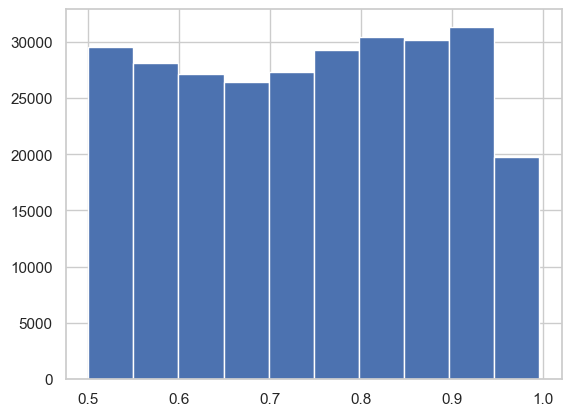

In [34]:
incorrect_with_high_probability_fp["predicted_prob"].hist()

In [35]:
#  take the high prob of fp

incorrect_with_high_probability_fp_high_prob = incorrect_with_high_probability_fp[incorrect_with_high_probability_fp["predicted_prob"]>0.7]

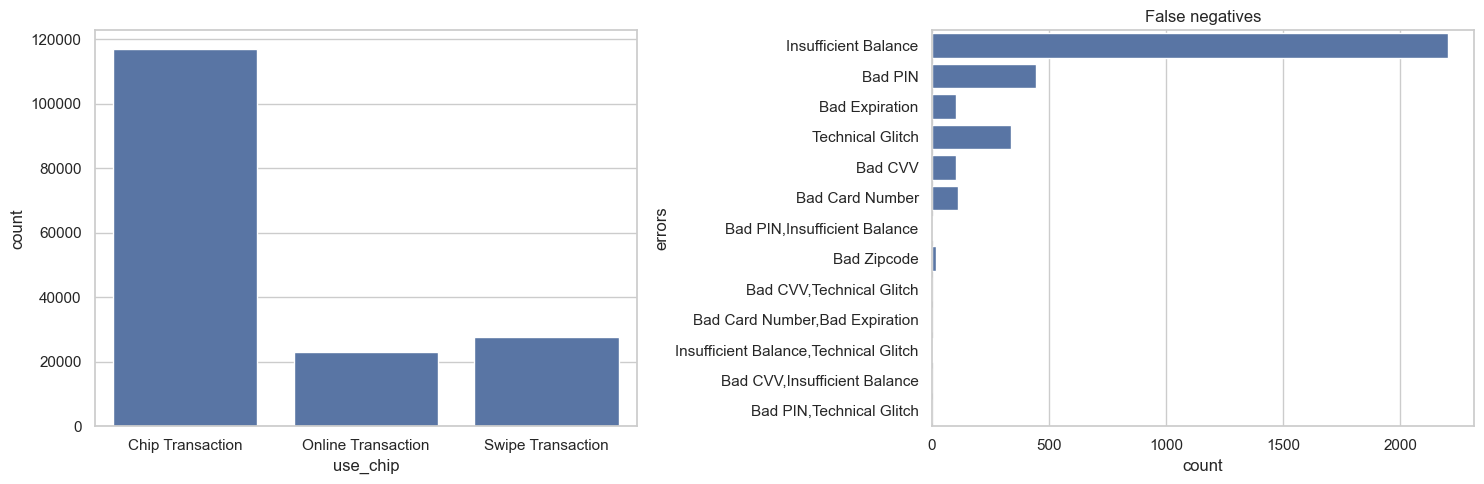

In [36]:
fig, axes = plt.subplots(1,2, figsize=(15,5))
plt.title("False negatives")

sns.countplot(data=incorrect_with_high_probability_fp_high_prob, x = "use_chip", ax = axes[0])
sns.countplot(data=incorrect_with_high_probability_fp_high_prob, y = "errors", ax = axes[1])
plt.tight_layout()


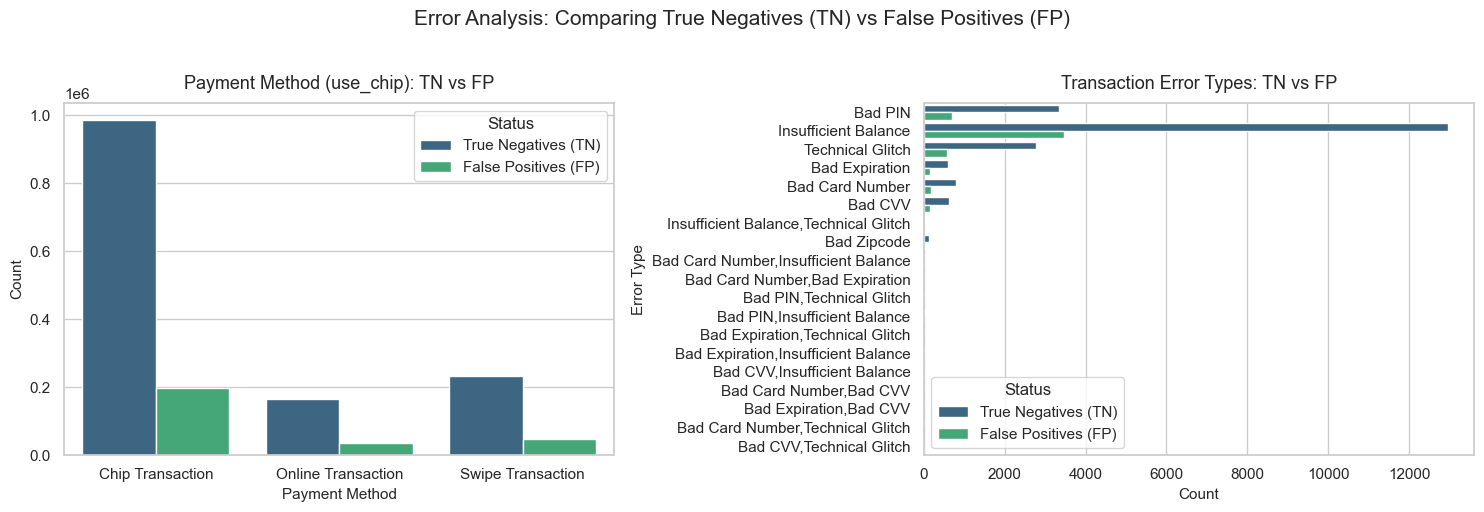

In [37]:
tn_df = correct_classified_tn.copy()
tn_df["Classification"] = "True Negatives (TN)"

fp_df = incorrect_with_high_probability_fp.copy()
fp_df["Classification"] = "False Positives (FP)"

df_compare = pd.concat([tn_df, fp_df], ignore_index=True)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df_compare, x="use_chip", hue="Classification", ax=axes[0], palette="viridis")
axes[0].set_title("Payment Method (use_chip): TN vs FP", fontsize=13, pad=10)
axes[0].set_xlabel("Payment Method", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].legend(title="Status")

sns.countplot(data=df_compare, y="errors", hue="Classification", ax=axes[1], palette="viridis")
axes[1].set_title("Transaction Error Types: TN vs FP", fontsize=13, pad=10)
axes[1].set_xlabel("Count", fontsize=11)
axes[1].set_ylabel("Error Type", fontsize=11)
axes[1].legend(title="Status")

plt.suptitle("Error Analysis: Comparing True Negatives (TN) vs False Positives (FP)", fontsize=15, y=1.02)

plt.tight_layout()
plt.show()

looks like online transactions mislead the model

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_27358/1586515095.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=online_trxs, x="prediction_status", order=["True Negative (TN)", "False Positive (FP)", "True Positive (TP)", "False Negative (FN)"],palette="viridis", ax=axes[0, 0])
/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_27358/1586515095.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=online_trxs,x="prediction_status",y="amount",order=["True Negative (TN)", "False Positive (FP)", "True Positive (TP)", "False Negative (FN)"],palette="viridis",ax=axes[0, 1])


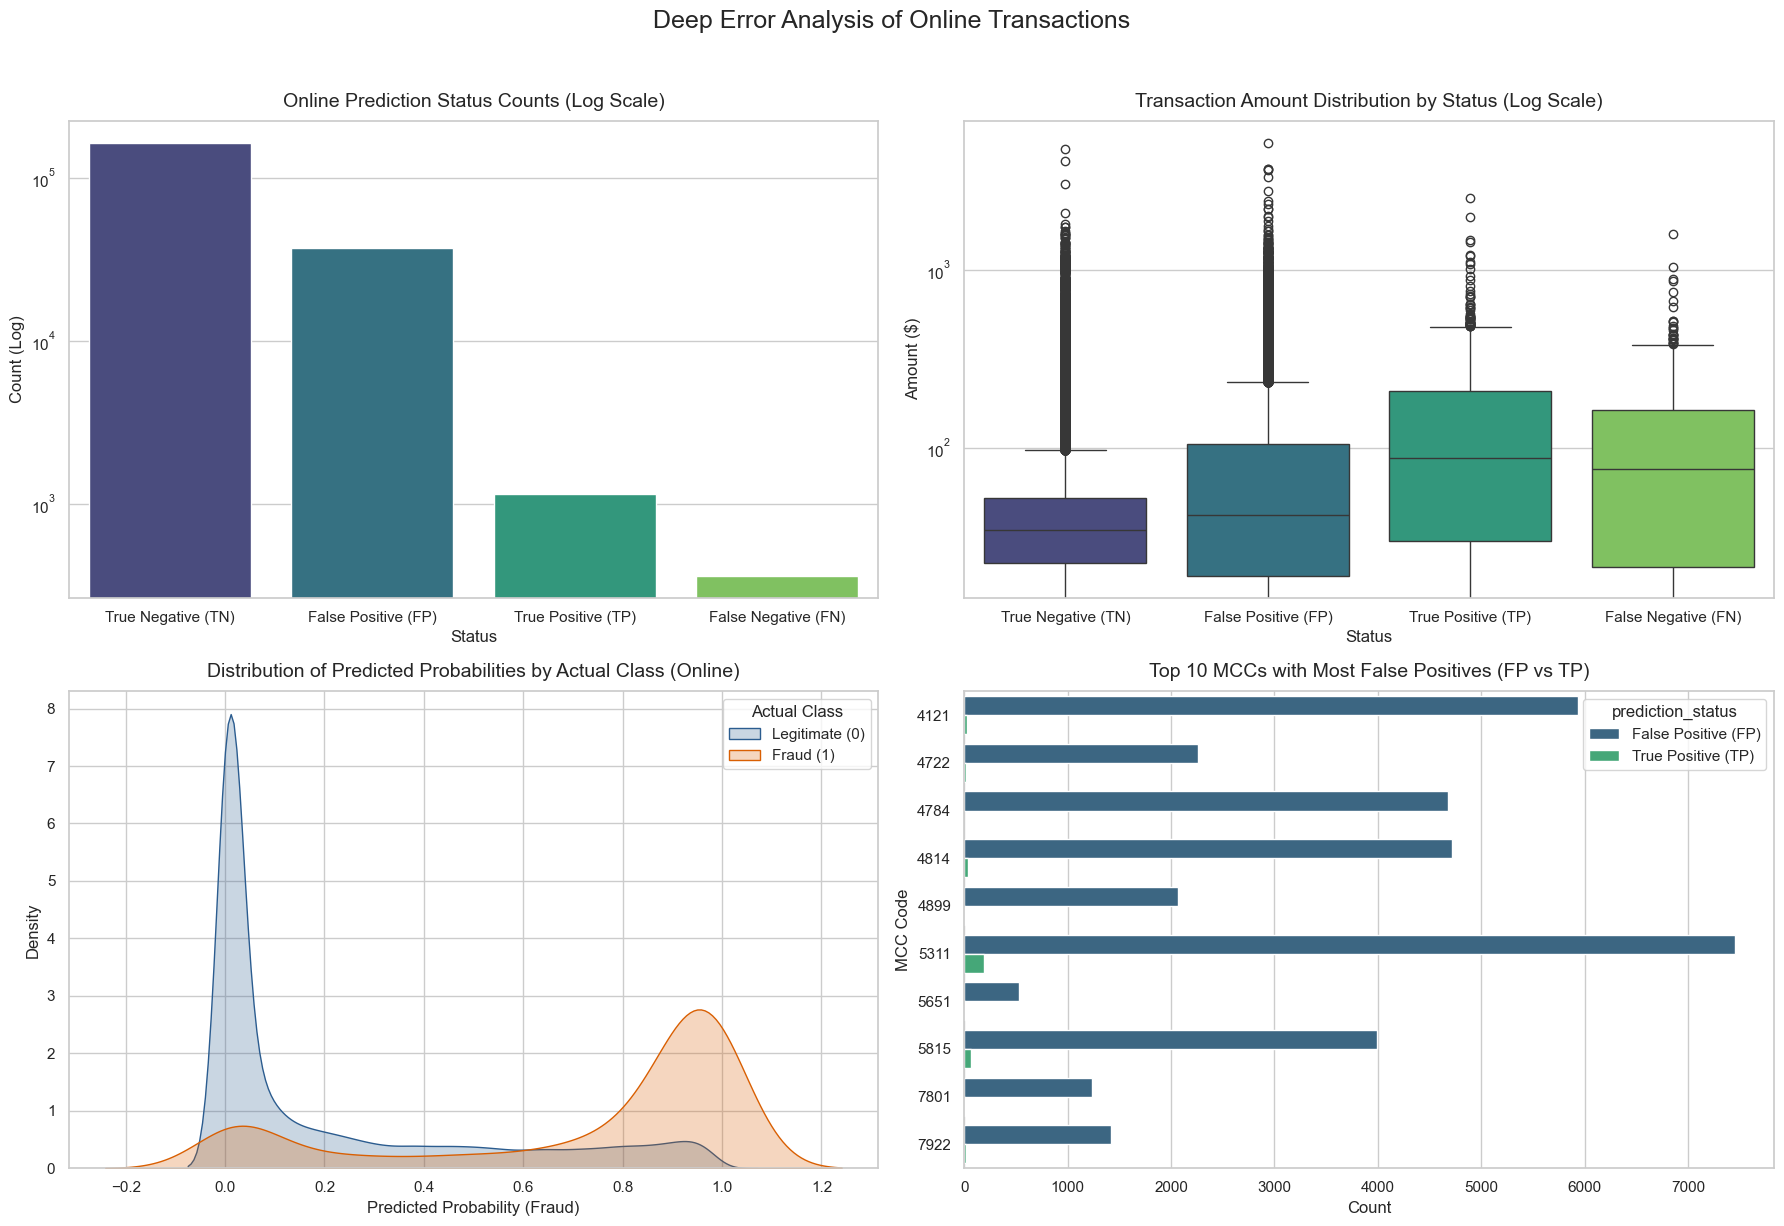

In [38]:
online_trxs = df[df["merchant_city"]=="ONLINE"].copy()

online_trxs["date"] = pd.to_datetime(online_trxs["date"])
online_trxs["hour"] = online_trxs["date"].dt.hour

conditions = [(online_trxs["target"] == "No") & (online_trxs["predicted_class"] == "No"),(online_trxs["target"] == "No") & (online_trxs["predicted_class"] == "Yes"),(online_trxs["target"] == "Yes") & (online_trxs["predicted_class"] == "Yes"),(online_trxs["target"] == "Yes") & (online_trxs["predicted_class"] == "No")]
choices = ["True Negative (TN)", "False Positive (FP)", "True Positive (TP)", "False Negative (FN)"]
online_trxs["prediction_status"] = np.select(conditions, choices, default="Unknown")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))


sns.countplot(data=online_trxs, x="prediction_status", order=["True Negative (TN)", "False Positive (FP)", "True Positive (TP)", "False Negative (FN)"],palette="viridis", ax=axes[0, 0])
axes[0, 0].set_yscale("log") 
axes[0, 0].set_title("Online Prediction Status Counts (Log Scale)", fontsize=14, pad=10)
axes[0, 0].set_xlabel("Status", fontsize=12)
axes[0, 0].set_ylabel("Count (Log)", fontsize=12)

sns.boxplot(data=online_trxs,x="prediction_status",y="amount",order=["True Negative (TN)", "False Positive (FP)", "True Positive (TP)", "False Negative (FN)"],palette="viridis",ax=axes[0, 1])
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Transaction Amount Distribution by Status (Log Scale)", fontsize=14, pad=10)
axes[0, 1].set_xlabel("Status", fontsize=12)
axes[0, 1].set_ylabel("Amount ($)", fontsize=12)


legit_probs = online_trxs[online_trxs["target"] == "No"]["predicted_prob"].dropna()
fraud_probs = online_trxs[online_trxs["target"] == "Yes"]["predicted_prob"].dropna()

if len(legit_probs) > 1:
    sns.kdeplot(x=legit_probs, fill=True, color="#2b5c8f", label="Legitimate (0)", ax=axes[1, 0])
if len(fraud_probs) > 1:
    sns.kdeplot(x=fraud_probs, fill=True, color="#d95f02", label="Fraud (1)", ax=axes[1, 0])

axes[1, 0].legend(title="Actual Class")
axes[1, 0].set_title("Distribution of Predicted Probabilities by Actual Class (Online)", fontsize=14, pad=10)
axes[1, 0].set_xlabel("Predicted Probability (Fraud)", fontsize=12)
axes[1, 0].set_ylabel("Density", fontsize=12)


top_fp_mccs = online_trxs[online_trxs["prediction_status"] == "False Positive (FP)"]["mcc"].value_counts().head(10).index
mcc_compare_df = online_trxs[online_trxs["mcc"].isin(top_fp_mccs)]

sns.countplot(data=mcc_compare_df,y="mcc",hue="prediction_status",hue_order=["False Positive (FP)", "True Positive (TP)"],palette="viridis",ax=axes[1, 1])
axes[1, 1].set_title("Top 10 MCCs with Most False Positives (FP vs TP)", fontsize=14, pad=10)
axes[1, 1].set_xlabel("Count", fontsize=12)
axes[1, 1].set_ylabel("MCC Code", fontsize=12)

plt.suptitle("Deep Error Analysis of Online Transactions", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

online transactions and mcc codes produce the highest damage

# Explore FN

In [39]:
incorrect_with_high_probability_fn

,date,id,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,has_bad_cvv,has_bad_pin,has_insufficient_balance,has_technical_glitch,insufficient_balance_count_1h,bad_cvv_count_1h,bad_pin_count_1h,tech_glitch_count_1h,predicted_prob,predicted_class
335231,2016-03-22 10:16:00,17547786,1956,1125,31.22,Online Transaction,60569,ONLINE,NaN,NaN,...,0,0,0,0,0.0,0.0,0.0,0.0,0.015389,No
335291,2016-03-22 10:37:00,17547895,366,2934,48.29,Online Transaction,47399,ONLINE,NaN,NaN,...,0,0,0,0,0.0,0.0,0.0,0.0,0.008434,No
336262,2016-03-22 16:02:00,17549684,856,4851,16.43,Online Transaction,60569,ONLINE,NaN,NaN,...,0,0,0,0,0.0,0.0,0.0,0.0,0.003553,No
340554,2016-03-24 10:49:00,17557462,1697,4306,0.70,Online Transaction,32858,ONLINE,NaN,NaN,...,0,0,0,0,0.0,0.0,0.0,0.0,0.018218,No
340813,2016-03-24 12:16:00,17557938,1060,4291,3.01,Online Transaction,82026,ONLINE,NaN,NaN,...,0,0,0,0,0.0,0.0,0.0,0.0,0.079821,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1972950,2017-12-21 13:13:00,20555388,112,1134,111.31,Chip Transaction,99370,Rome,Italy,NaN,...,0,0,0,0,0.0,0.0,0.0,0.0,0.013299,No
1981372,2017-12-24 19:38:00,20570850,4,4201,1.25,Chip Transaction,43293,Rome,Italy,NaN,...,0,0,0,0,0.0,0.0,0.0,0.0,0.008946,No
1986366,2017-12-26 16:02:00,20579976,619,5648,403.85,Chip Transaction,86410,Rome,Italy,NaN,...,0,0,0,0,0.0,0.0,0.0,0.0,0.007287,No
1989319,2017-12-27 19:18:00,20585382,1284,6066,8.36,Chip Transaction,22204,Rome,Italy,NaN,...,0,0,0,0,0.0,0.0,0.0,0.0,0.003848,No


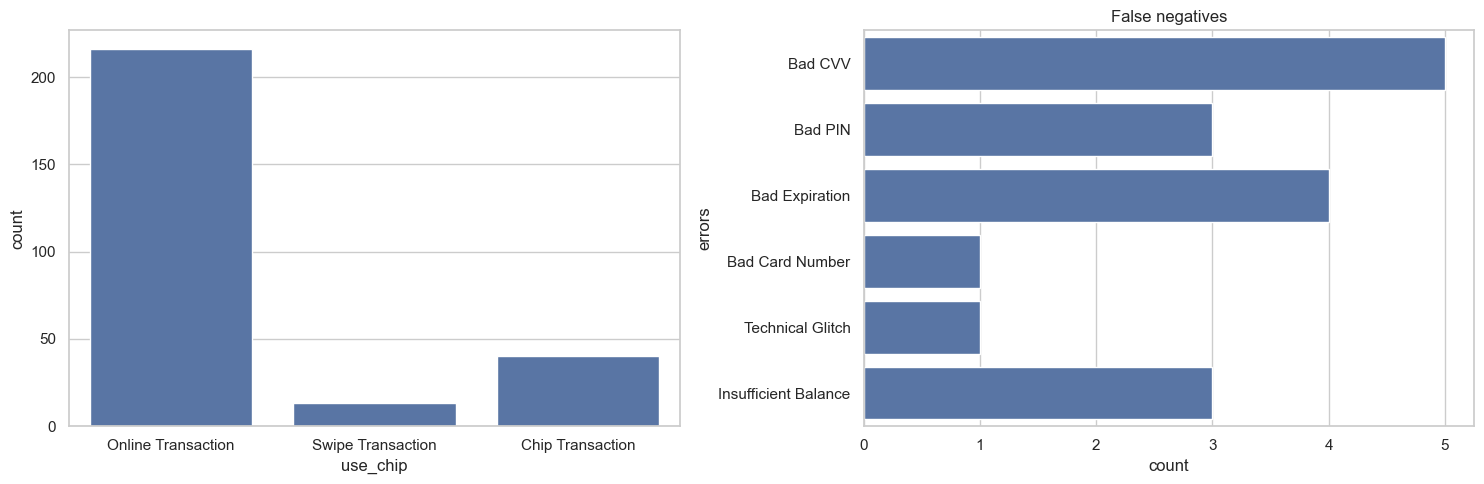

In [40]:
fig, axes = plt.subplots(1,2, figsize=(15,5))
plt.title("False negatives")

sns.countplot(data=incorrect_with_high_probability_fn, x = "use_chip", ax = axes[0])
sns.countplot(data=incorrect_with_high_probability_fn, y = "errors", ax = axes[1])
plt.tight_layout()


we fail on online transactions

In [41]:
df = df.sort_values(["card_id", "date"])
df["time_since_last_trx"] = (df.groupby("card_id")["date"].diff().dt.total_seconds() .fillna(-1).astype(float))

In [42]:
df.groupby("target")[["time_since_last_trx"]].median()

,time_since_last_trx
target,
No,65100.0
Yes,13260.0


In [43]:
online_trxs = df[df["merchant_city"]=="ONLINE"]


In [44]:
online_trxs_fraud = online_trxs[online_trxs["target"]=="Yes"]
online_trxs_not_fraud = online_trxs[online_trxs["target"]=="No"]

In [45]:
online_trxs.columns

Index(['date', 'id', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors', 'target', 'prev_fraud_count', 'online_history_ratio',
       'trx_count_1h', 'trx_amount_1h', 'has_bad_cvv', 'has_bad_pin',
       'has_insufficient_balance', 'has_technical_glitch',
       'insufficient_balance_count_1h', 'bad_cvv_count_1h', 'bad_pin_count_1h',
       'tech_glitch_count_1h', 'predicted_prob', 'predicted_class',
       'time_since_last_trx'],
      dtype='object')

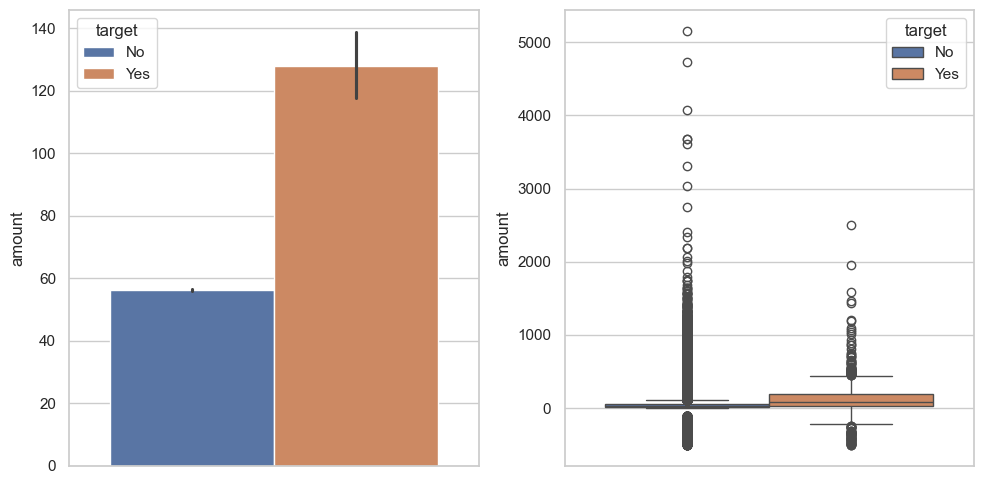

In [46]:
fig, axis = plt.subplots(1,2, figsize=(10,5))
sns.barplot(data=online_trxs, y = "amount", hue="target", errorbar="ci", ax = axis[0])
sns.boxplot(data=online_trxs, y = "amount", hue="target", ax = axis[1])
plt.tight_layout()

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_27358/4220792024.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=online_trxs_not_fraud, y=mcc_col, order=online_trxs_not_fraud[mcc_col].value_counts().head(10).index, ax=axes[0], palette="Blues_r")
/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_27358/4220792024.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=online_trxs_fraud, y=mcc_col, order=online_trxs_fraud[mcc_col].value_counts().head(10).index, ax=axes[1], palette="Oranges_r")


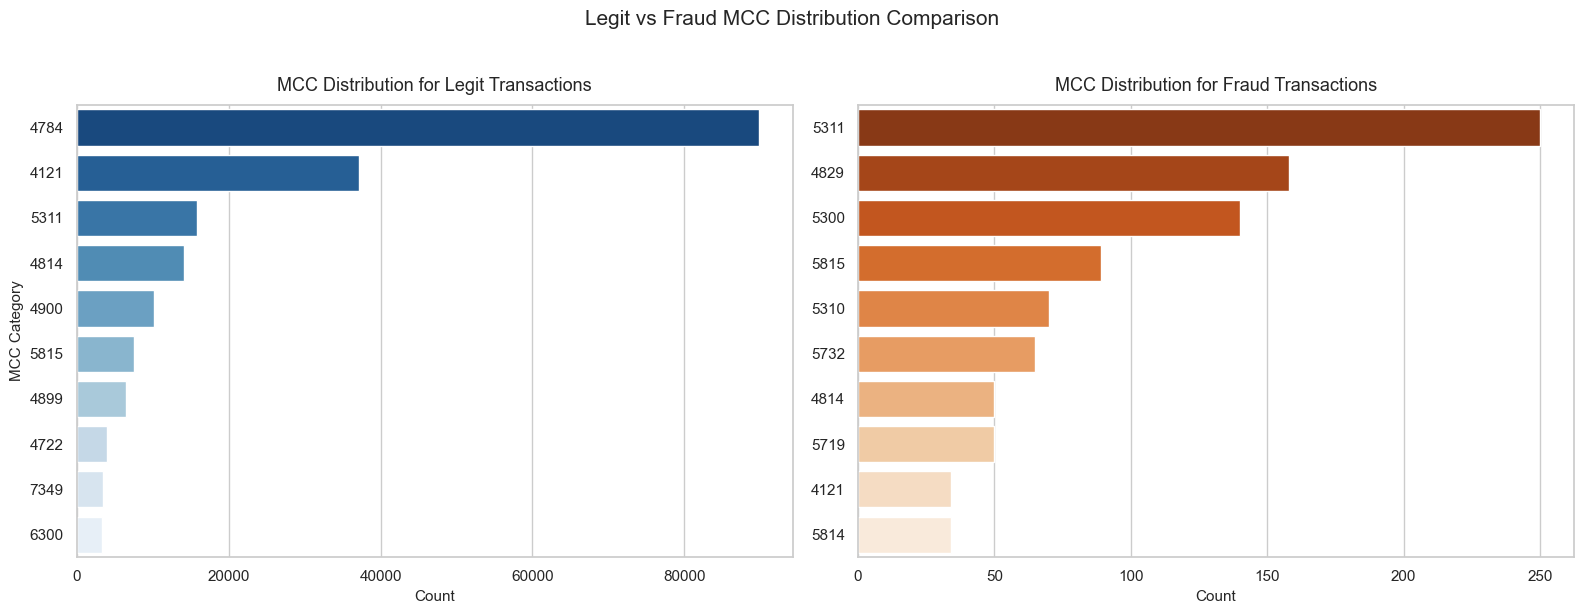

In [47]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")


mcc_col = "mcc_category" if "mcc_category" in online_trxs.columns else "mcc"

sns.countplot(data=online_trxs_not_fraud, y=mcc_col, order=online_trxs_not_fraud[mcc_col].value_counts().head(10).index, ax=axes[0], palette="Blues_r")
axes[0].set_title("MCC Distribution for Legit Transactions", fontsize=13, pad=10)
axes[0].set_xlabel("Count", fontsize=11)
axes[0].set_ylabel("MCC Category", fontsize=11)

sns.countplot(data=online_trxs_fraud, y=mcc_col, order=online_trxs_fraud[mcc_col].value_counts().head(10).index, ax=axes[1], palette="Oranges_r")
axes[1].set_title("MCC Distribution for Fraud Transactions", fontsize=13, pad=10)
axes[1].set_xlabel("Count", fontsize=11)
axes[1].set_ylabel("") 

plt.suptitle("Legit vs Fraud MCC Distribution Comparison", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Success! Filtered 202291 online transactions.


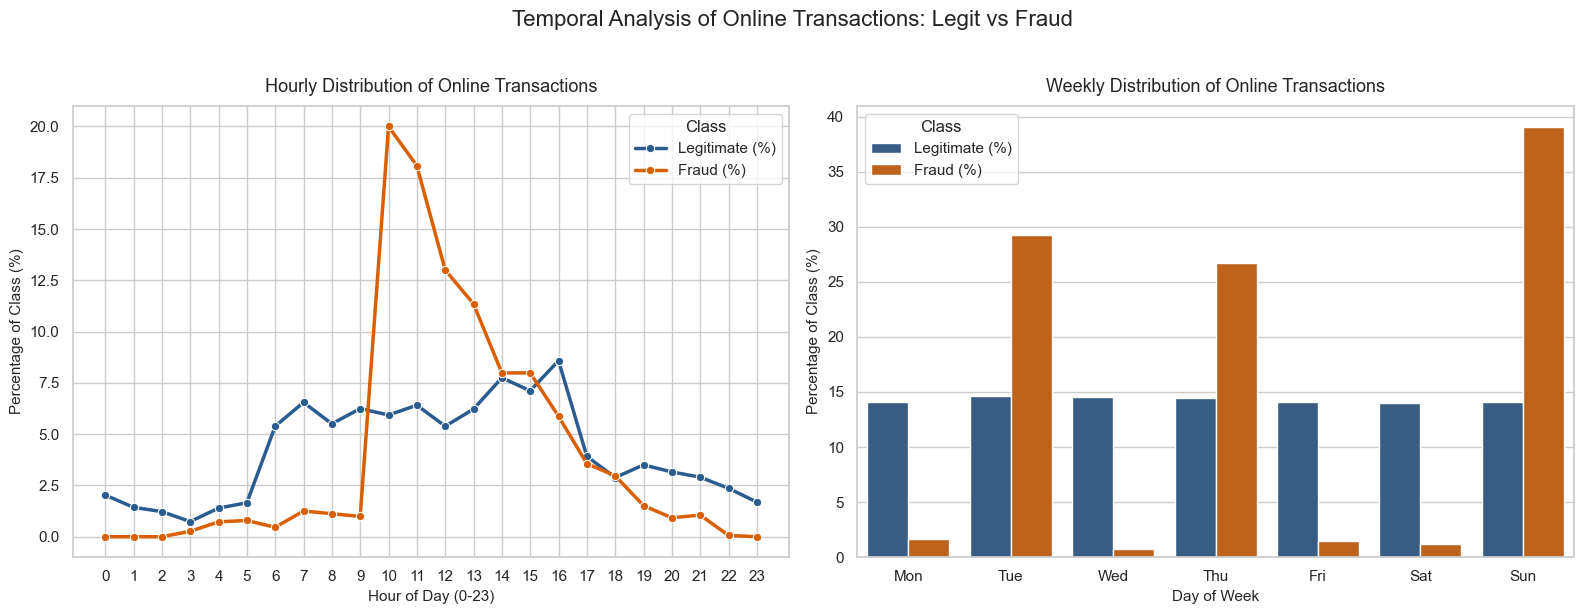

In [48]:


online_trxs = df[df["use_chip"].str.lower().str.contains("online", na=False)].copy()

print(f"Success! Filtered {online_trxs.shape[0]} online transactions.")

online_trxs["date"] = pd.to_datetime(online_trxs["date"])
online_trxs["hour"] = online_trxs["date"].dt.hour
online_trxs["day_of_week"] = online_trxs["date"].dt.dayofweek

day_names = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
online_trxs["day_name"] = online_trxs["day_of_week"].map(day_names)

online_trxs["target_numeric"] = online_trxs["target"].apply(lambda x: 1 if str(x).lower().strip() in ["yes", "1", "1.0"] else 0)

legit_hourly = (online_trxs[online_trxs["target_numeric"] == 0]["hour"].value_counts(normalize=True).reindex(range(24), fill_value=0) * 100)

fraud_hourly = (online_trxs[online_trxs["target_numeric"] == 1]["hour"].value_counts(normalize=True).reindex(range(24), fill_value=0) * 100)

hourly_df = pd.DataFrame({"Hour": legit_hourly.index,"Legitimate (%)": legit_hourly.values,"Fraud (%)": fraud_hourly.values}).melt(id_vars="Hour", var_name="Class", value_name="Percentage")

day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

legit_daily = (online_trxs[online_trxs["target_numeric"] == 0]["day_name"].value_counts(normalize=True).reindex(day_order, fill_value=0) * 100)

fraud_daily = (online_trxs[online_trxs["target_numeric"] == 1]["day_name"].value_counts(normalize=True).reindex(day_order, fill_value=0) * 100)

daily_df = pd.DataFrame({"Day": legit_daily.index,"Legitimate (%)": legit_daily.values,"Fraud (%)": fraud_daily.values}).melt(id_vars="Day", var_name="Class", value_name="Percentage")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=hourly_df, x="Hour", y="Percentage", hue="Class", marker="o", linewidth=2.5, palette=["#2b5c8f", "#d95f02"], ax=axes[0])
axes[0].set_title("Hourly Distribution of Online Transactions", fontsize=13, pad=10)
axes[0].set_xlabel("Hour of Day (0-23)", fontsize=11)
axes[0].set_ylabel("Percentage of Class (%)", fontsize=11)
axes[0].set_xticks(range(0, 24))

sns.barplot(data=daily_df, x="Day", y="Percentage", hue="Class",palette=["#2b5c8f", "#d95f02"], ax=axes[1])
axes[1].set_title("Weekly Distribution of Online Transactions", fontsize=13, pad=10)
axes[1].set_xlabel("Day of Week", fontsize=11)
axes[1].set_ylabel("Percentage of Class (%)", fontsize=11)

plt.suptitle("Temporal Analysis of Online Transactions: Legit vs Fraud", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [49]:
df["temp_is_online"] = df["use_chip"].str.lower().str.contains("online", na=False).astype(int)
df["temp_prev_online_count"] = (df.groupby("card_id")["temp_is_online"].transform(lambda x: x.shift(1).fillna(0).cumsum()))
df["temp_total_prev_count"] = df.groupby("card_id").cumcount()
df["online_history_ratio"] = (df["temp_prev_online_count"] / df["temp_total_prev_count"]).fillna(0.0)
df = df.drop(columns=["temp_is_online", "temp_prev_online_count", "temp_total_prev_count"])

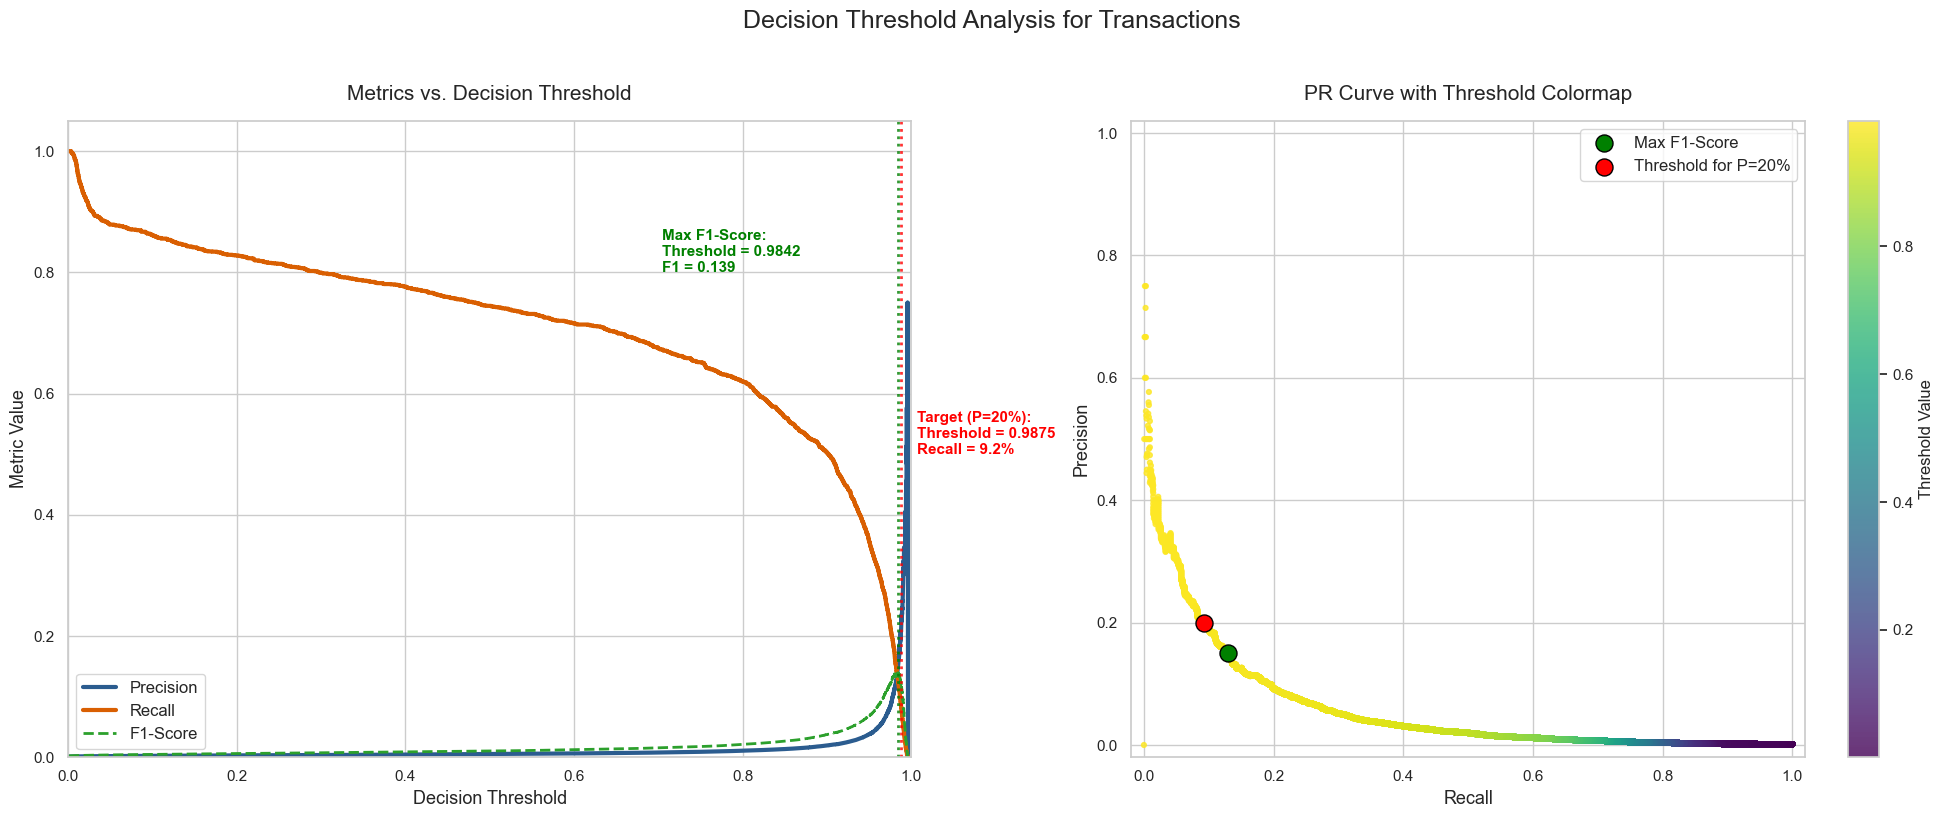

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve

def plot_threshold_analysis(df):
    # Handle missing values & binary target mapping
    valid_data = df[['target', 'predicted_prob']].dropna()
    y_true = (valid_data["target"] == "Yes").astype(int)
    y_prob = valid_data["predicted_prob"]
    
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    p_curve = precisions[:-1]
    r_curve = recalls[:-1]
    f1_curve = f1_scores[:-1]
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    sns.set_theme(style="whitegrid")
    
    ax1 = axes[0]
    ax1.plot(thresholds, p_curve, label="Precision", color="#2b5c8f", lw=3)
    ax1.plot(thresholds, r_curve, label="Recall", color="#d95f02", lw=3)
    ax1.plot(thresholds, f1_curve, label="F1-Score", color="#2ca02c", lw=2, linestyle="--")
    
    best_f1_idx = np.argmax(f1_curve)
    best_thresh_f1 = thresholds[best_f1_idx]
    best_f1_val = f1_curve[best_f1_idx]
    
    target_p = 0.20
    p_target_indices = np.where(p_curve >= target_p)[0]
    if len(p_target_indices) > 0:
        thresh_p_target = thresholds[p_target_indices[0]]
        recall_p_target = r_curve[p_target_indices[0]]
        
        ax1.axvline(x=thresh_p_target, color="red", linestyle=":", alpha=0.8, lw=2)
        ax1.text(thresh_p_target + 0.02, 0.5, f"Target (P={target_p:.0%}):\nThreshold = {thresh_p_target:.4f}\nRecall = {recall_p_target:.1%}", color="red", fontsize=11, weight="bold")
        
    ax1.axvline(x=best_thresh_f1, color="green", linestyle=":", alpha=0.8, lw=2)
    ax1.text(best_thresh_f1 - 0.28, 0.8, f"Max F1-Score:\nThreshold = {best_thresh_f1:.4f}\nF1 = {best_f1_val:.3f}", color="green", fontsize=11, weight="bold")
    
    ax1.set_title("Metrics vs. Decision Threshold", fontsize=15, pad=15)
    ax1.set_xlabel("Decision Threshold", fontsize=13)
    ax1.set_ylabel("Metric Value", fontsize=13)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1.05)
    ax1.legend(fontsize=12, loc="lower left")
    
    ax2 = axes[1]
    sc = ax2.scatter(r_curve, p_curve, c=thresholds, cmap="viridis", s=12, alpha=0.8)
    
    cbar = plt.colorbar(sc, ax=ax2)
    cbar.set_label("Threshold Value", fontsize=12)
    
    ax2.scatter(recalls[:-1][best_f1_idx], precisions[:-1][best_f1_idx], color="green", s=150, edgecolors="black", zorder=5, label="Max F1-Score")
    if len(p_target_indices) > 0:
        ax2.scatter(recalls[:-1][p_target_indices[0]], precisions[:-1][p_target_indices[0]], color="red", s=150, edgecolors="black", zorder=5, label=f"Threshold for P={target_p:.0%}")
        
    ax2.set_title("PR Curve with Threshold Colormap", fontsize=15, pad=15)
    ax2.set_xlabel("Recall", fontsize=13)
    ax2.set_ylabel("Precision", fontsize=13)
    ax2.set_xlim(-0.02, 1.02)
    ax2.set_ylim(-0.02, 1.02)
    ax2.legend(fontsize=12, loc="upper right")
    
    plt.suptitle("Decision Threshold Analysis for Transactions", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

plot_threshold_analysis(df)